## Perceptron Learning Algorithm

Đây là thuật toán phân loại nhị phân

### Bài toán

Cho một tập dữ liệu $\mathbf{X} = [\mathbf{x}_1, ..., \mathbf{x}_N]$ và tập label tương ứng $\mathbf{Y} = [y_1, ..., y_N]$ với $y_i \in \set{-1, 1}$. Nhiệm vụ của bạn là xác định một siêu phẳng (hyperplace): $f(\mathbf{w}) = 0$ ngăn cách giữa hai tập có nhãn khác nhau.

### Siêu phẳng
Với mỗi điểm dữ liệu $\mathbf{x}_i$ có $d$ chiều, thì siêu phẳng sẽ là:
$$
f(\mathbf{w}) = w_0 + w_1x_1 + ... + w_d.x_d = \mathbf{\bar{x}}\mathbf{w} = 0
$$
Với $\mathbf{\bar{x}} = [1, x_1, ..., x_d]$ và $\mathbf{w} = [w_0, w_1, ..., w_d]^T$
### Hàm mất mát
Giả sử tập các điểm của nhãn bằng 1 là $\mathbf{A}$, tập các điểm có nhãn bằng -1 là $\mathbf{B}$.

Giả sử, đối với các điểm dữ liệu $\mathbf{a}_i \in \mathbf{A}$ ta có:
$$
f(\mathbf{a}_i) > 0
$$
Và, đối với các điểm dữ liệu $\mathbf{b}_i \in \mathbf{B}$ ta có:
$$
f(\mathbf{b}_i) < 0
$$

Một điểm dữ liệu $\mathbf{x}_i$ được phân sai nhóm là khi:
$$
-y_if(\mathbf{x}_i)> 0
$$
Tập các điểm bị phân sai nhóm là $\mathcal{M}$ Khi đó hàm mất mát được định nghĩa như sau:
$$
\mathcal{L}(w) 
= -\sum_{x_i \in \mathcal{M}}{y_i f(\mathbf{x}_i)} 
= -\sum_{x_i \in \mathcal{M}}{y_i \mathbf{\bar{x}}_i \mathbf{w}}
= -\left(\sum_{x_i \in \mathcal{M}}{y_i \mathbf{\bar{x}}_i}\right) \mathbf{w}
$$
Tính đạo hàm riêng
$$
\nabla \mathcal{L} = -\left(\sum_{x_i \in \mathcal{M}}{y_i \mathbf{\bar{x}}_i}\right)^T
$$
Đạo hàm riêng của hàm trên phụ thuộc vào tập $\mathcal{M}$ nên ta sử dụng GD hoặc SGD để tối ưu hàm mất mát

##### **Thiết lập công thức sử dụng GD**
B1. Khởi tạo $\mathbf{w}_0$ ngẫu nhiên, khởi tạo $t = 0$  
B2. Cập nhật $t = t + 1$  
B3. Xác định tập $\mathcal{M}$  
B4. Xác định đạo hàm riêng $\nabla \mathcal{L}$ trên tập $\mathcal{M}$  
$$
\nabla \mathcal{L} = -\left(\sum_{x_i \in \mathcal{M}}{y_i \mathbf{\bar{x}}_i}\right)^T
$$
B5. Tiến hành cập nhật $\mathbf{w}_t = \mathbf{w}_{t - 1} - \eta \nabla \mathcal{L}$  
B6. Kiểm tra điều kiện dừng, nếu thỏa mãn thì kết thúc, không thì quay lại B2  

##### **Thiết lập công thức sử dụng SGD**
B1. Khởi tạo $\mathbf{w}_0$ ngẫu nhiên, khởi tạo $t = 0$  
B2. Cập nhật $t = t + 1$  
B3. Xác định tập $\mathcal{M}$  
B4. Xác định đạo hàm riêng $\nabla \mathcal{L}$ trên giá trị bất kỳ $\mathbf{x}_ i \in \mathcal{M}$  
$$
\nabla \mathcal{L} = -(y_i\mathbf{\bar{x}}_i)^T
$$
B5. Tiến hành cập nhật $\mathbf{w}_t = \mathbf{w}_{t - 1} - \eta \nabla \mathcal{L}$  
B6. Kiểm tra điều kiện dừng, nếu thỏa mãn thì kết thúc, không thì quay lại B2  


In [320]:
import numpy as np
import matplotlib.pyplot as plt

class PLA:
    def __init__(self):
        self.w = None

    def fit(self, X, y, type = 'SGD', eta = 0.002):
        one = np.ones((X.shape[0], 1))
        Xbar = np.concatenate((one, X), axis = 1)
        self.w = np.random.rand(Xbar.shape[1]).reshape(-1, 1)
        # find M & label (L)
        for it in range(1000):
            M = []
            L = []
            for i in range(len(Xbar)):
                xbar = Xbar[i]
                yhat = np.sign(xbar @ self.w).item()
                if yhat != y[i]:
                    M.append(xbar)
                    L.append(y[i])
            if len(M) == 0:
                break
            M = np.array(M) 
            L = np.array(L)
            if type == 'GD':
                grad = - M.T @ L
            else:
                idx = np.random.randint(0, M.shape[0])
                xi = M[idx : idx+1 :]
                yi = L[idx : idx+1 :]
                grad = - xi.T @ yi
            self.w = self.w - eta * grad
        self.w /= self.w[2]
        return it
    
    def predict(self, X):
        one  = np.ones((X.shape[0], 1))
        Xbar = np.concatenate((one, X), axis = 1)
        y    = []
        for xbar in Xbar:
            y.append(np.sign(xbar @ self.w))
        return np.array(y)


In [321]:
means = [[-1,0],[1,0]]
cov   = [[.3,.2],[.2,.3]]
N = 100
A = np.random.multivariate_normal(means[0], cov, N)
B = np.random.multivariate_normal(means[1], cov, N)
X = np.concatenate((A, B), axis=0)
y = np.concatenate((np.ones(N), -1*np.ones(N))).reshape(-1, 1)

In [322]:
def func(w, x):
    return -(w[0] + w[1] * x) / w[2]

def draw(func, w, A, B, start=-2, end=2, num_point=400):
    plt.figure(figsize=[6, 6])
    plt.axis('equal')
    plt.xlim(start, end)
    plt.ylim(start, end)
    x = np.linspace(start, end, num_point)
    y = func(w, x)
    plt.plot(x, y, label='f(x)', color='blue')
    x_A = A[:, 0]
    y_A = A[:, 1]
    x_B = B[:, 0]
    y_B = B[:, 1]
    plt.scatter(x_A, y_A, color='blue', marker='o')
    plt.scatter(x_B, y_B, color='red', marker='o')
    plt.show()

In [323]:
model = PLA()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


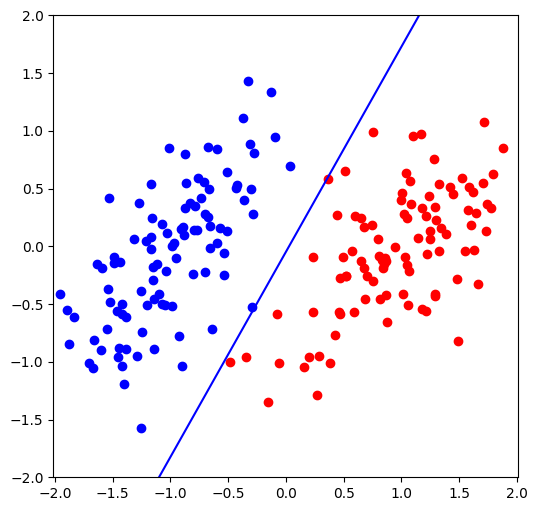

In [324]:
model.fit(X, y, type='GD')
draw(func, model.w, A, B)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


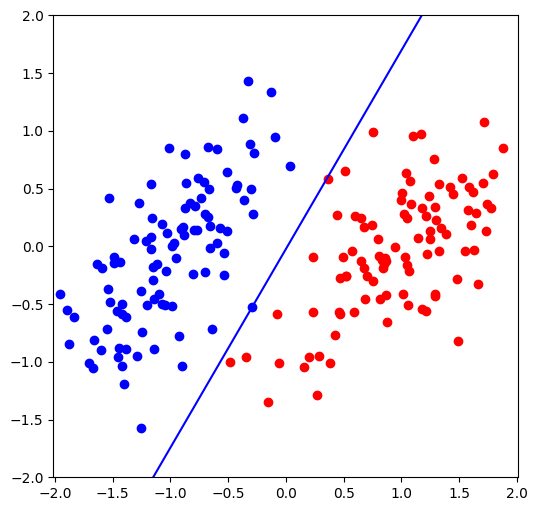

In [325]:
model.fit(X, y, type='SGD')
draw(func, model.w, A, B)

## Biểu diễn dưới dạng Neural Network

Bài toán PLA có thể biểu diễn dưới dạng Neural Network theo như hình vẽ

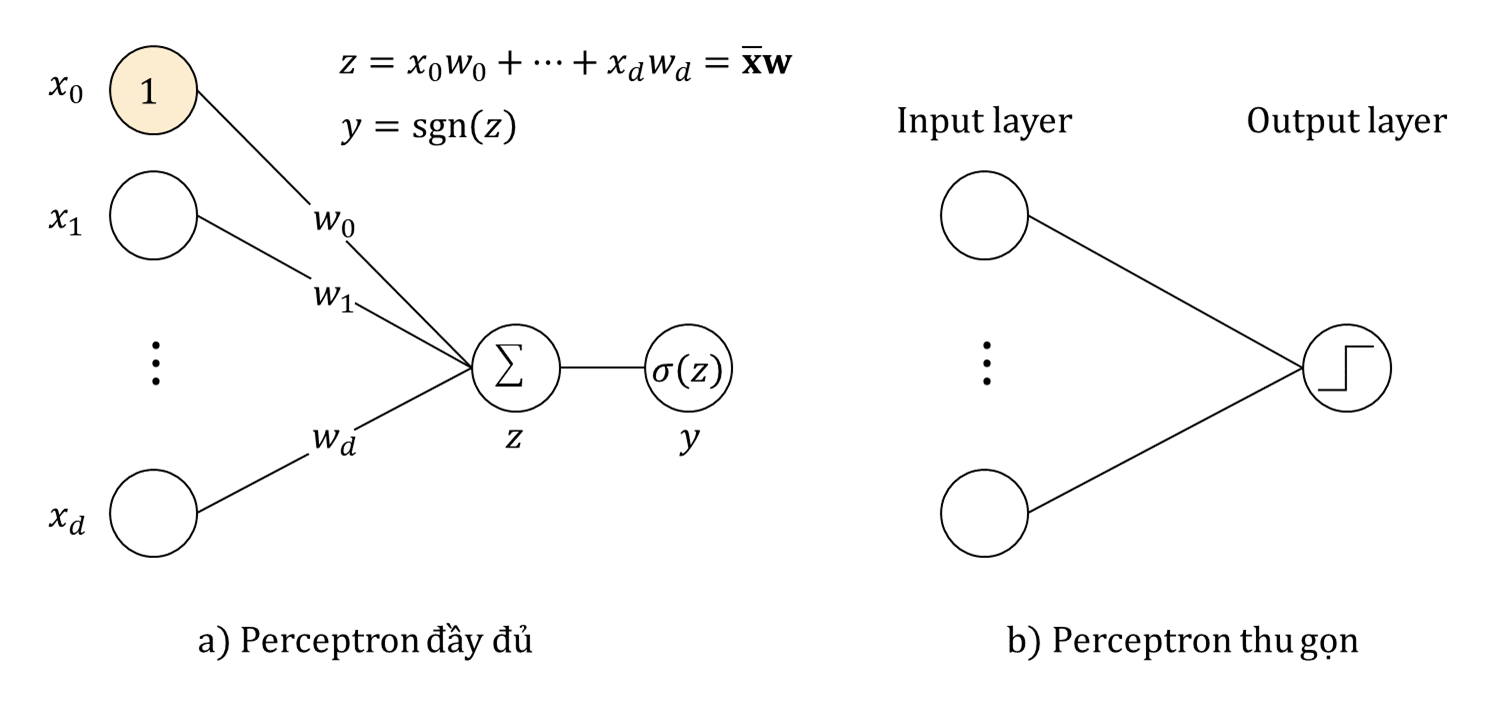

## MLP (Multi-Layer Perceptron)

**MLP** là một mạng neural nhiều lớp Perceptron, gồm:
- Một lớp đầu vào
- Một hoặc nhiều lớp ẩn
- Một lớp đầu ra

MLP học bằng cách lan truyền tiến (forward propagation) và cập nhật bằng lan truyền ngược (backpropagation).

Cấu trúc mạng:
$$
\text{Output} = f(W_2 \cdot f(W_1 \cdot x + b_1) + b_2)
$$

Trong đó $f$ là **activation function** như ReLU, Sigmoid, Tanh.


## Activation Functions

### 1. **Sigmoid**
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
- Ưu: dễ hiểu, đầu ra trong khoảng (0,1)
- Nhược: dễ gây vanishing gradient

### 2. **Tanh**
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$
- Đầu ra trong khoảng (-1,1)
- Cũng có vấn đề gradient nhỏ

### 3. **ReLU**
$$
f(x) = \max(0, x)
$$
- Đơn giản, tính nhanh, ít bị vanishing gradient
- Có thể gây chết neuron nếu gradient = 0 quá nhiều
